<a href="https://colab.research.google.com/github/saminNazmus201/DeepLearningDataScienceUppsala/blob/master/Exercise1Ass2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from utils import load_mnist

In [3]:
!unzip -q MNIST.zip   #unzip the file

In [4]:
x_train_np, y_train_np, x_test_np, y_test_np = load_mnist()

In [16]:
x_train = torch.from_numpy(x_train_np).float()
y_train = torch.from_numpy(y_train_np).long() # Labels should be Long for CrossEntropy
x_test = torch.from_numpy(x_test_np).float()
y_test = torch.from_numpy(y_test_np).long()

In [6]:
def initialize_network(layer_sizes):
    K = len(layer_sizes) - 1
    all_weights = [None] * K
    all_biases = [None] * K

    for k in range(K):
        n_in, n_out = layer_sizes[k], layer_sizes[k+1]

        # PyTorch uses randn; requires_grad=True enables Autograd
        # He initialization: std = sqrt(2/n_in)
        all_weights[k] = torch.randn(n_out, n_in) * torch.sqrt(torch.tensor(2.0/n_in))
        all_weights[k].requires_grad = True

        all_biases[k] = torch.full((n_out, 1), 0.01, requires_grad=True)

    return all_weights, all_biases

In [7]:
def forward_pass(X, all_weights, all_biases, activation_type='ReLU'):
    K = len(all_weights)
    h = X


    act_fn = F.relu if activation_type == 'ReLU' else torch.sigmoid

    for k in range(K):

        f = F.linear(h, all_weights[k], all_biases[k].flatten())

        if k < K - 1:
            h = act_fn(f)
        else:
            h = f # Output layer (logits)

    return h

In [8]:
def train_model(x_train, y_train, x_test, y_test, model_architecture,
                num_epochs=10, learning_rate=0.1, batch_size=64, activation_type='ReLU'):

    all_weights, all_biases = initialize_network(model_architecture)
    train_costs, test_costs = [], []
    train_accs, test_accs = [], []

    for epoch in range(num_epochs):

        indices = torch.randperm(x_train.size(0))

        for i in range(0, x_train.size(0), batch_size):
            batch_idx = indices[i:i+batch_size]
            x_mini, y_mini = x_train[batch_idx], y_train[batch_idx]


            logits = forward_pass(x_mini, all_weights, all_biases, activation_type)


            loss = F.cross_entropy(logits, y_mini)


            loss.backward()


            with torch.no_grad():
                for k in range(len(all_weights)):
                    all_weights[k] -= learning_rate * all_weights[k].grad
                    all_biases[k] -= learning_rate * all_biases[k].grad

                    # Manually zero gradients for next batch
                    all_weights[k].grad.zero_()
                    all_biases[k].grad.zero_()

        # Evaluation
        with torch.no_grad():
            train_logits = forward_pass(x_train, all_weights, all_biases, activation_type)
            test_logits = forward_pass(x_test, all_weights, all_biases, activation_type)

            train_loss = F.cross_entropy(train_logits, y_train).item()
            test_loss = F.cross_entropy(test_logits, y_test).item()

            train_acc = (train_logits.argmax(dim=1) == y_train).float().mean().item()
            test_acc = (test_logits.argmax(dim=1) == y_test).float().mean().item()

        train_costs.append(train_loss)
        test_costs.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        print(f"Epoch {epoch}: Loss {train_loss:.4f}, Test Acc {test_acc:.4f}")

    return all_weights, all_biases, train_costs, test_costs, train_accs, test_accs

In [17]:
# Convert everything to the format PyTorch's F.cross_entropy expects
x_train = torch.tensor(x_train).float()
x_test = torch.tensor(x_test).float()

# If labels are one-hot, convert to indices; if already indices, just ensure they are Long
if y_train.ndim > 1:
    y_train = torch.tensor(y_train).argmax(dim=1).long()
    y_test = torch.tensor(y_test).argmax(dim=1).long()
else:
    y_train = torch.tensor(y_train).long()
    y_test = torch.tensor(y_test).long()

/tmp/ipykernel_243/2261970919.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train = torch.tensor(x_train).float()
/tmp/ipykernel_243/2261970919.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test = torch.tensor(x_test).float()
/tmp/ipykernel_243/2261970919.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train).argmax(dim=1).long()
/tmp/ipykernel_243/2261970919.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone

Epoch 0: Loss 0.2317, Test Acc 0.9353
Epoch 1: Loss 0.1654, Test Acc 0.9509
Epoch 2: Loss 0.1234, Test Acc 0.9607
Epoch 3: Loss 0.1032, Test Acc 0.9656
Epoch 4: Loss 0.0867, Test Acc 0.9688
Epoch 5: Loss 0.0888, Test Acc 0.9669
Epoch 6: Loss 0.0687, Test Acc 0.9706
Epoch 7: Loss 0.0588, Test Acc 0.9749
Epoch 8: Loss 0.0576, Test Acc 0.9733
Epoch 9: Loss 0.0477, Test Acc 0.9756
Epoch 10: Loss 0.0433, Test Acc 0.9764
Epoch 11: Loss 0.0409, Test Acc 0.9774
Epoch 12: Loss 0.0378, Test Acc 0.9772
Epoch 13: Loss 0.0340, Test Acc 0.9762
Epoch 14: Loss 0.0383, Test Acc 0.9754
Epoch 15: Loss 0.0322, Test Acc 0.9757
Epoch 16: Loss 0.0279, Test Acc 0.9772
Epoch 17: Loss 0.0256, Test Acc 0.9777
Epoch 18: Loss 0.0229, Test Acc 0.9775
Epoch 19: Loss 0.0214, Test Acc 0.9778
Epoch 20: Loss 0.0206, Test Acc 0.9781
Epoch 21: Loss 0.0182, Test Acc 0.9777
Epoch 22: Loss 0.0166, Test Acc 0.9779
Epoch 23: Loss 0.0163, Test Acc 0.9782
Epoch 24: Loss 0.0150, Test Acc 0.9775
Epoch 25: Loss 0.0140, Test Acc 0.9

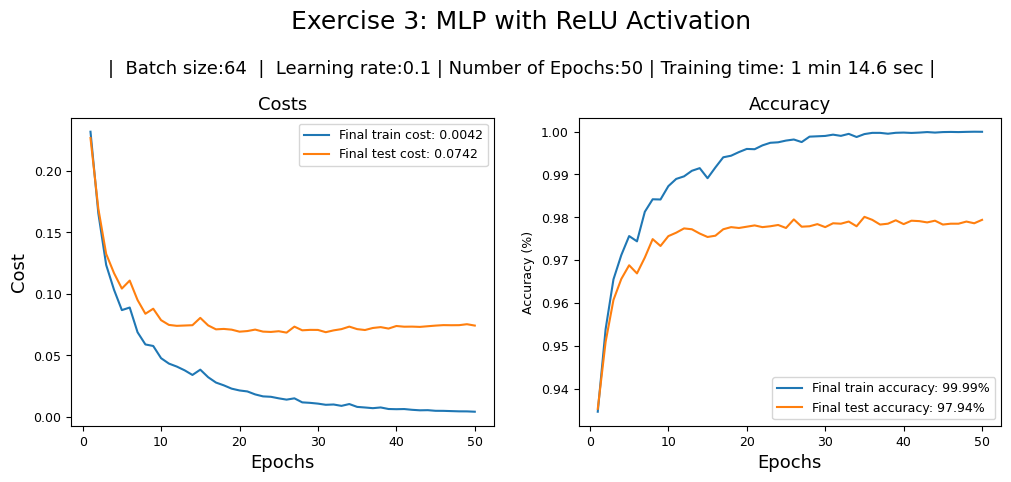

In [19]:
# import torch
# import time
# from utils import training_curve_plot

# # 1. Configuration
# arch_mlp = [784, 128, 10]
# learning_rate = 0.1
# batch_size = 64
# num_epochs = 50

# if y_train_pt.dim() > 1:
#     y_train_final = torch.argmax(y_train_pt, dim=1)
#     y_test_final = torch.argmax(y_test_pt, dim=1)
# else:
#     y_train_final = y_train_pt
#     y_test_final = y_test_pt

# # Ensure they are Long type
# y_train_final = y_train_final.long()
# y_test_final = y_test_final.long()

# start_time = time.time()

# # 3. Train with ReLU
# # Note: Ensure x_train_pt is float32
# w_relu, b_relu, t_costs_r, v_costs_r, t_accs_r, v_accs_r = train_model(
#     x_train_pt.float(),
#     y_train_final,
#     x_test_pt.float(),
#     y_test_final,
#     model_architecture=arch_mlp,
#     num_epochs=num_epochs,
#     learning_rate=learning_rate,
#     batch_size=batch_size,
#     activation_type='ReLU'
# )

# # 4. Visualization
# training_curve_plot(
#     "Exercise 3: MLP with ReLU Activation (PyTorch)",
#     t_costs_r, v_costs_r, t_accs_r, v_accs_r,
#     batch_size, learning_rate, num_epochs, time.time() - start_time
# )

import time
from utils import training_curve_plot

# Architecture and Parameters
arch_mlp = [784, 128, 10]
learning_rate = 0.1
batch_size = 64
num_epochs = 50

start_time = time.time()

# Train with ReLU
w_relu, b_relu, t_costs_r, v_costs_r, t_accs_r, v_accs_r = train_model(
    x_train, y_train, x_test, y_test,
    model_architecture=arch_mlp,
    num_epochs=num_epochs,
    learning_rate=learning_rate,
    batch_size=batch_size,
    activation_type='ReLU'
)

# Plotting
training_curve_plot(
    "Exercise 3: MLP with ReLU Activation",
    t_costs_r, v_costs_r, t_accs_r, v_accs_r,
    batch_size, learning_rate, num_epochs, time.time() - start_time
)